In [ ]:
from pathlib import Path
import json

path = Path("../data/results")

for file in path.glob("*-codeql.json"):
    print(f"\n📁 {file.name}")

    with open(file) as f:
        data = json.load(f)

    print("Keys:", data.keys())
    print("Total issues:", data.get("total_issues"))
    print("Keys en issues[0]:", list(data["issues"]
          [0].keys()) if data.get("issues") else "No issues")


📁 Flowise-codeql.json
Keys: dict_keys(['total_issues', 'issues_by_severity', 'issues', 'sarif_metadata'])
Total issues: 0
Keys en issues[0]: No issues

📁 FlowiseChatEmbed-codeql.json
Keys: dict_keys(['total_issues', 'issues_by_severity', 'issues', 'sarif_metadata'])
Total issues: 0
Keys en issues[0]: No issues

📁 FlowiseDocs-codeql.json
Keys: dict_keys(['total_issues', 'issues_by_severity', 'issues', 'sarif_metadata'])
Total issues: 0
Keys en issues[0]: No issues

📁 FlowiseEmbedReact-codeql.json
Keys: dict_keys(['total_issues', 'issues_by_severity', 'issues', 'sarif_metadata'])
Total issues: 0
Keys en issues[0]: No issues

📁 FlowisePy-codeql.json
Keys: dict_keys(['total_issues', 'issues_by_severity', 'issues', 'sarif_metadata'])
Total issues: 2
Keys en issues[0]: ['rule_id', 'rule_index', 'level', 'message', 'file', 'region', 'kind', 'properties']


In [1]:
from pathlib import Path
import json

path = Path("../data/results")

files = list(path.glob("*-codeql.json"))

len(files), files[:3]

(5,
 [PosixPath('../data/results/Flowise-codeql.json'),
  PosixPath('../data/results/FlowiseChatEmbed-codeql.json'),
  PosixPath('../data/results/FlowiseDocs-codeql.json')])

In [2]:
sample = json.load(open(files[0]))

type(sample), sample.keys()

(dict,
 dict_keys(['total_issues', 'issues_by_severity', 'issues', 'sarif_metadata']))

In [ ]:
import pandas as pd
from pathlib import Path
import json

path = Path("../data/results")

records = []

for file in path.glob("*-codeql.json"):
    with open(file) as f:
        data = json.load(f)

    repo = file.stem
    issues = data.get("issues", [])

    for issue in issues:
        records.append({
            "repo": repo,
            "rule_id": issue.get("rule_id"),
            "severity": issue.get("level"),
            "message": issue.get("message"),
            "file": issue.get("file"),
            "line": issue.get("region", {}).get("startLine"),
            "kind": issue.get("kind"),
            "tags": issue.get("properties", {}).get("tags")
        })

df_codeql = pd.DataFrame(records)

df_codeql

,repo,rule_id,severity,message,file,line,kind,tags
0,FlowiseChatEmbed-codeql,js/missing-rate-limiting,warning,This route handler performs [a file system acc...,server.js,148,notApplicable,None
1,FlowiseChatEmbed-codeql,js/missing-rate-limiting,warning,This route handler performs [a file system acc...,server.js,152,notApplicable,None
2,FlowiseChatEmbed-codeql,js/request-forgery,warning,The [URL](1) of this request depends on a [use...,server.js,363,notApplicable,None
3,FlowiseChatEmbed-codeql,js/cors-permissive-configuration,warning,CORS Origin allows broad access due to [permis...,server.js,141,notApplicable,None


In [9]:
df_codeql.shape
df_codeql["repo"].value_counts()
df_codeql["severity"].value_counts()

severity
warning    4
Name: count, dtype: int64

In [ ]:
def extract_cwe(tags):
    if not tags:
        return None
    for t in tags:
        if "CWE" in t:
            return t
    return None


df_codeql["cwe"] = df_codeql["tags"].apply(extract_cwe)

In [12]:
df_codeql.groupby("repo").size()
df_codeql.groupby("severity").size()
df_codeql.groupby("rule_id").size()

rule_id
js/cors-permissive-configuration    1
js/missing-rate-limiting            2
js/request-forgery                  1
dtype: int64

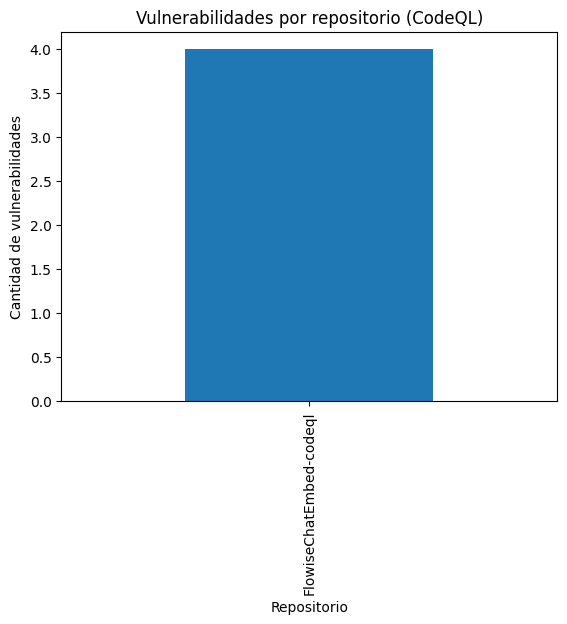

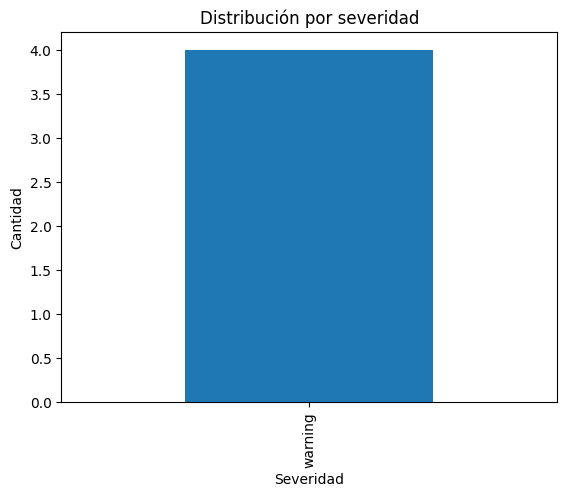

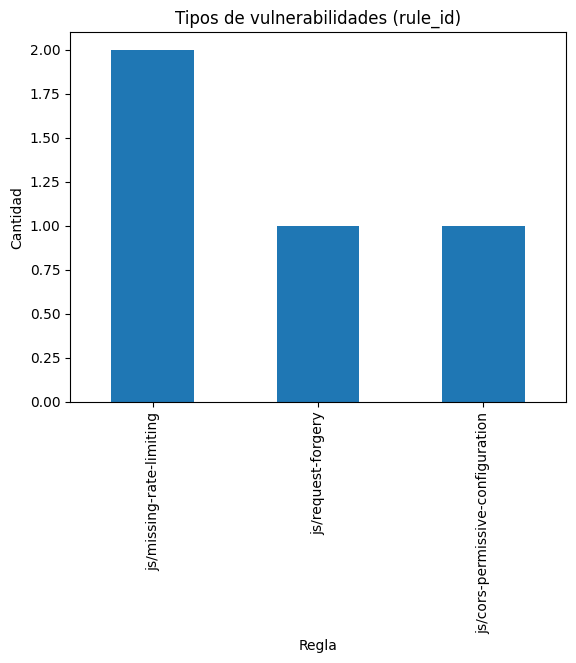

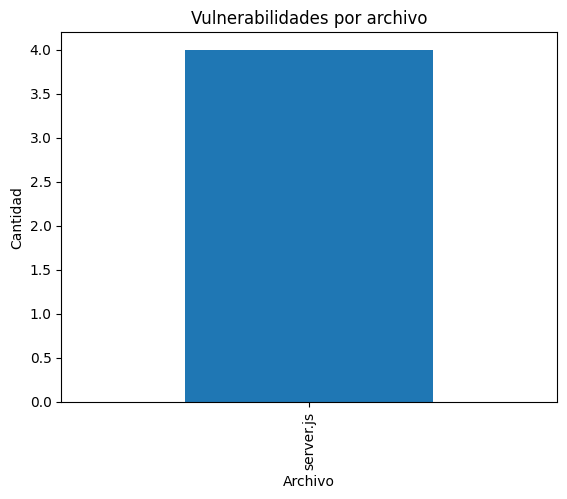

,repo,rule_id,severity,message,file,line,kind,tags
0,FlowiseChatEmbed-codeql,js/missing-rate-limiting,warning,This route handler performs [a file system acc...,server.js,148,notApplicable,None
1,FlowiseChatEmbed-codeql,js/missing-rate-limiting,warning,This route handler performs [a file system acc...,server.js,152,notApplicable,None
2,FlowiseChatEmbed-codeql,js/request-forgery,warning,The [URL](1) of this request depends on a [use...,server.js,363,notApplicable,None
3,FlowiseChatEmbed-codeql,js/cors-permissive-configuration,warning,CORS Origin allows broad access due to [permis...,server.js,141,notApplicable,None


In [ ]:
# Recreate df_codeql and generate basic plots (no color specification)

import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt

path = Path("../data/results")

records = []

for file in path.glob("*-codeql.json"):
    with open(file) as f:
        data = json.load(f)

    repo = file.stem
    issues = data.get("issues", [])

    for issue in issues:
        records.append({
            "repo": repo,
            "rule_id": issue.get("rule_id"),
            "severity": issue.get("level"),
            "message": issue.get("message"),
            "file": issue.get("file"),
            "line": issue.get("region", {}).get("startLine"),
            "kind": issue.get("kind"),
            "tags": issue.get("properties", {}).get("tags")
        })

df_codeql = pd.DataFrame(records)

# 1. Distribución de vulnerabilidades por repo
if not df_codeql.empty:
    df_codeql["repo"].value_counts().plot(kind="bar")
    plt.title("Vulnerabilidades por repositorio (CodeQL)")
    plt.xlabel("Repositorio")
    plt.ylabel("Cantidad de vulnerabilidades")
    plt.show()

# 2. Distribución por severidad
if not df_codeql.empty:
    df_codeql["severity"].value_counts().plot(kind="bar")
    plt.title("Distribución por severidad")
    plt.xlabel("Severidad")
    plt.ylabel("Cantidad")
    plt.show()

# 3. Tipos de vulnerabilidades (rule_id)
if not df_codeql.empty:
    df_codeql["rule_id"].value_counts().plot(kind="bar")
    plt.title("Tipos de vulnerabilidades (rule_id)")
    plt.xlabel("Regla")
    plt.ylabel("Cantidad")
    plt.show()

# 4. Vulnerabilidades por archivo
if not df_codeql.empty:
    df_codeql["file"].value_counts().plot(kind="bar")
    plt.title("Vulnerabilidades por archivo")
    plt.xlabel("Archivo")
    plt.ylabel("Cantidad")
    plt.show()

# Show dataframe for reference
df_codeql